# 🤖 02 — Modeling, Evaluation & Interpretasi SHAP
## Sistem Prediksi Kelulusan Mahasiswa
**UAS Pembelajaran Mesin 2025/2026 — Universitas Dian Nuswantoro**  
**Mahasiswa:** Carvin Gildan

---
### Tujuan Notebook
- Melatih 3 model ML: Logistic Regression, Random Forest, XGBoost
- Hyperparameter tuning dengan GridSearchCV
- Menangani imbalanced data dengan SMOTE
- Evaluasi komprehensif (Accuracy, F1, AUC, Confusion Matrix, ROC)
- Interpretasi model dengan SHAP


In [30]:
# ── Import Library ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


## 1. Load Dataset

In [31]:
# ── Load Data ───────────────────────────────────────────────
df = pd.read_csv('../data/raw/dataset_mahasiswa.csv')
print(f"Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Distribusi target:")
print(df['lulus_tepat_waktu'].value_counts().rename({1:'Tepat Waktu',0:'Terlambat'}))

NUM = ['ipk','sks','kehadiran','nilai_rata','jumlah_cuti','jumlah_mengulang','lama_studi_semester','status_kerja','organisasi']
CAT = ['penghasilan_ortu','jalur_masuk']
TARGET = 'lulus_tepat_waktu'

X = df[NUM + CAT]
y = df[TARGET]
print(f"\nFitur numerik  : {NUM}")
print(f"Fitur kategorik: {CAT}")


Dataset: 1000 baris x 12 kolom
Distribusi target:
lulus_tepat_waktu
Tepat Waktu    830
Terlambat      170
Name: count, dtype: int64

Fitur numerik  : ['ipk', 'sks', 'kehadiran', 'nilai_rata', 'jumlah_cuti', 'jumlah_mengulang', 'lama_studi_semester', 'status_kerja', 'organisasi']
Fitur kategorik: ['penghasilan_ortu', 'jalur_masuk']


## 2. Pembagian Data (Train / Validation / Test)

In [32]:
# ── Split Data ──────────────────────────────────────────────
# Split 1: pisahkan test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split 2: bagi sisa menjadi train (80%) dan val (20% dari sisa = 16% total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print("PEMBAGIAN DATA:")
print(f"  Training set  : {len(X_train):,} sampel ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Validation set: {len(X_val):,} sampel ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test set      : {len(X_test):,} sampel ({len(X_test)/len(X)*100:.0f}%)")
print(f"  Total         : {len(X):,} sampel")


PEMBAGIAN DATA:
  Training set  : 640 sampel (64%)
  Validation set: 160 sampel (16%)
  Test set      : 200 sampel (20%)
  Total         : 1,000 sampel


## 3. Preprocessing Pipeline

In [33]:
# ── Preprocessing ───────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT),
])
print("✅ Preprocessor dibuat:")
print("   - StandardScaler untuk fitur numerik")
print("   - OneHotEncoder untuk fitur kategorik")


✅ Preprocessor dibuat:
   - StandardScaler untuk fitur numerik
   - OneHotEncoder untuk fitur kategorik


## 4. SMOTE — Menangani Imbalanced Data

Sebelum SMOTE:
  Tepat Waktu: 531 | Terlambat: 109

Sesudah SMOTE:
  Tepat Waktu: 531 | Terlambat: 531
  Rasio      : 50% : 50% ✅


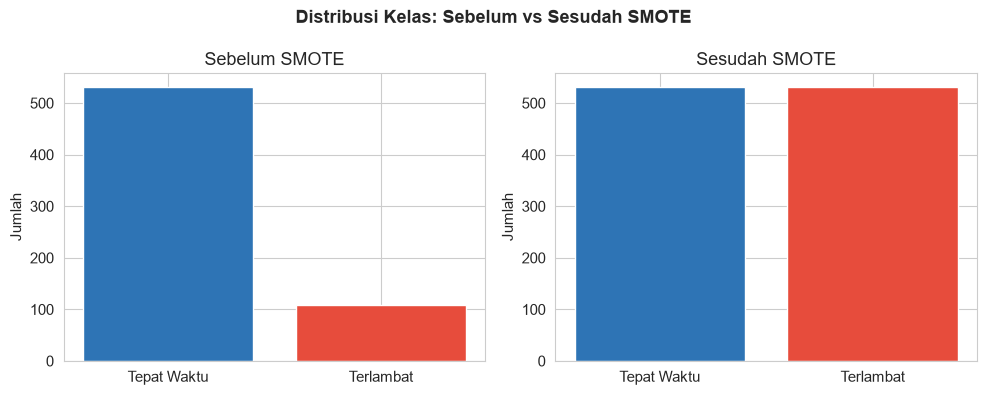

In [34]:
# ── SMOTE ───────────────────────────────────────────────────
print("Sebelum SMOTE:")
print(f"  Tepat Waktu: {y_train.sum()} | Terlambat: {(y_train==0).sum()}")

# Encode kategorik untuk SMOTE
X_train_enc = X_train.copy()
for col in CAT:
    X_train_enc[col] = LabelEncoder().fit_transform(X_train_enc[col])

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_enc, y_train)

print(f"\nSesudah SMOTE:")
print(f"  Tepat Waktu: {y_res.sum()} | Terlambat: {(y_res==0).sum()}")
print(f"  Rasio      : 50% : 50% ✅")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribusi Kelas: Sebelum vs Sesudah SMOTE', fontweight='bold')
for ax, y_data, title in zip(axes, [y_train, y_res], ['Sebelum SMOTE','Sesudah SMOTE']):
    counts = pd.Series(y_data).value_counts()
    ax.bar(['Tepat Waktu','Terlambat'], [counts.get(1,0), counts.get(0,0)],
           color=['#2E74B5','#E74C3C'], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Jumlah')
plt.tight_layout(); plt.show()


## 5. Training 3 Model ML

In [35]:
# ── Definisi Model ──────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('model', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                 use_label_encoder=False, eval_metric='logloss', random_state=42))
    ]),
}

# Training semua model
print("TRAINING MODEL...")
print("-" * 55)
trained = {}
for nama, pipe in models.items():
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    ypr = pipe.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, yp)
    f1  = f1_score(y_test, yp)
    auc = roc_auc_score(y_test, ypr)
    trained[nama] = pipe
    print(f"  ✔ {nama:<25} Acc={acc:.2%}  F1={f1:.4f}  AUC={auc:.4f}")

print("\n✅ Semua model berhasil dilatih!")


TRAINING MODEL...
-------------------------------------------------------
  ✔ Logistic Regression       Acc=90.50%  F1=0.9452  AUC=0.9440
  ✔ Random Forest             Acc=85.00%  F1=0.9167  AUC=0.9134
  ✔ XGBoost                   Acc=89.00%  F1=0.9357  AUC=0.9041

✅ Semua model berhasil dilatih!


## 6. Hyperparameter Tuning (GridSearchCV)

In [36]:
# ── GridSearchCV ────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grids = {
    'Logistic Regression': {
        'pipe': Pipeline([('prep',preprocessor),('model',LogisticRegression(max_iter=1000,random_state=42))]),
        'params': {'model__C':[0.01,0.1,1,10], 'model__solver':['lbfgs','liblinear']}
    },
    'Random Forest': {
        'pipe': Pipeline([('prep',preprocessor),('model',RandomForestClassifier(random_state=42))]),
        'params': {'model__n_estimators':[100,200], 'model__max_depth':[5,8,None]}
    },
    'XGBoost': {
        'pipe': Pipeline([('prep',preprocessor),('model',XGBClassifier(eval_metric='logloss',random_state=42))]),
        'params': {'model__n_estimators':[100,200], 'model__max_depth':[3,5], 'model__learning_rate':[0.05,0.1]}
    },
}

best_models = {}
print("HYPERPARAMETER TUNING (GridSearchCV 5-Fold)...")
print("-" * 55)
for nama, cfg in grids.items():
    gs = GridSearchCV(cfg['pipe'], cfg['params'], cv=cv, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[nama] = gs.best_estimator_
    print(f"\n  ✔ {nama}")
    print(f"     Best params : {gs.best_params_}")
    print(f"     Best CV F1  : {gs.best_score_:.4f}")

print("\n✅ Tuning selesai!")


HYPERPARAMETER TUNING (GridSearchCV 5-Fold)...
-------------------------------------------------------

  ✔ Logistic Regression
     Best params : {'model__C': 1, 'model__solver': 'lbfgs'}
     Best CV F1  : 0.9504

  ✔ Random Forest
     Best params : {'model__max_depth': None, 'model__n_estimators': 100}
     Best CV F1  : 0.9235

  ✔ XGBoost
     Best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
     Best CV F1  : 0.9296

✅ Tuning selesai!


## 7. Evaluasi Komprehensif

In [37]:
# ── Evaluasi Semua Model ────────────────────────────────────
results = []
for nama, model in best_models.items():
    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:,1]
    results.append({
        'Model': nama,
        'Accuracy':  round(accuracy_score(y_test,yp),4),
        'Precision': round(precision_score(y_test,yp),4),
        'Recall':    round(recall_score(y_test,yp),4),
        'F1-Score':  round(f1_score(y_test,yp),4),
        'ROC-AUC':   round(roc_auc_score(y_test,ypr),4),
        'CV-Acc':    round(cross_val_score(model,X_train,y_train,cv=5,scoring='accuracy').mean(),4),
    })

df_res = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print("PERBANDINGAN PERFORMA MODEL (Test Set)")
print("=" * 70)
print(df_res.to_string(index=False))

best_name = df_res.iloc[0]['Model']
print(f"\n🥇 Model Terbaik: {best_name}")

os.makedirs('../data/processed', exist_ok=True)
df_res.to_csv('../data/processed/model_results.csv', index=False)


PERBANDINGAN PERFORMA MODEL (Test Set)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV-Acc
Logistic Regression     0.925     0.9314  0.9819    0.9560   0.9438  0.9141
            XGBoost     0.875     0.8730  0.9940    0.9296   0.9173  0.8641
      Random Forest     0.865     0.8639  0.9940    0.9244   0.8992  0.8609

🥇 Model Terbaik: Logistic Regression


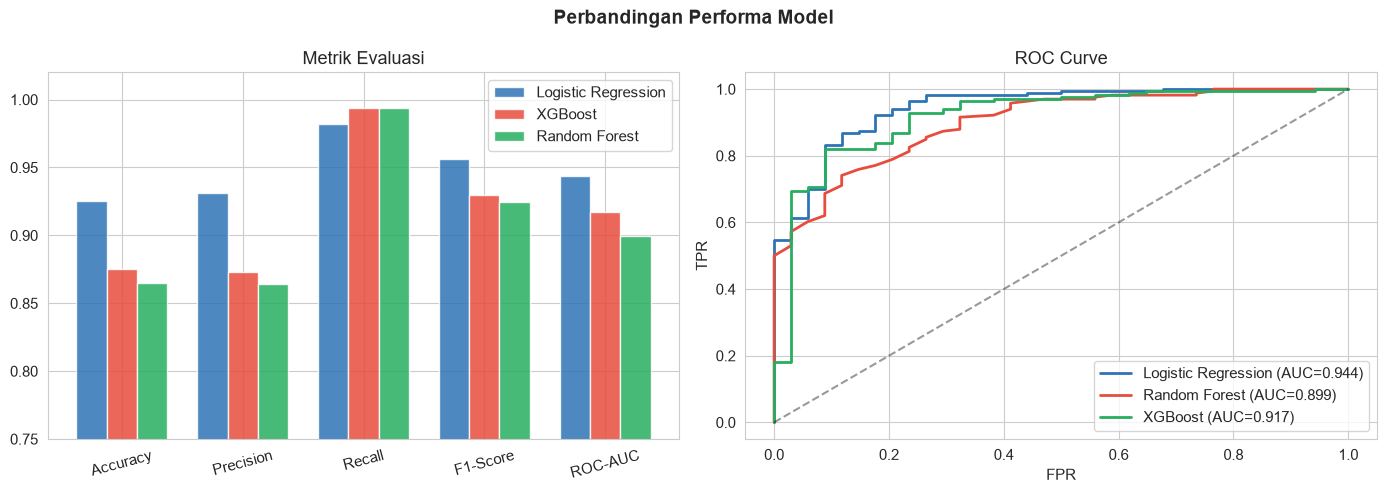

In [38]:
# ── Visualisasi Perbandingan ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Performa Model', fontsize=14, fontweight='bold')

metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(metrics)); w = 0.25
colors = ['#2E74B5','#E74C3C','#27AE60']
for i, row in df_res.iterrows():
    idx = list(df_res['Model']).index(row['Model'])
    axes[0].bar(x + idx*w, [row[m] for m in metrics], w, label=row['Model'],
                color=colors[idx], edgecolor='white', alpha=0.85)
axes[0].set_xticks(x+w); axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylim(0.75,1.02); axes[0].legend(); axes[0].set_title('Metrik Evaluasi')

# ROC Curve
for (nama, model), color in zip(best_models.items(), colors):
    ypr = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, ypr)
    auc = roc_auc_score(y_test, ypr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{nama} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/model_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


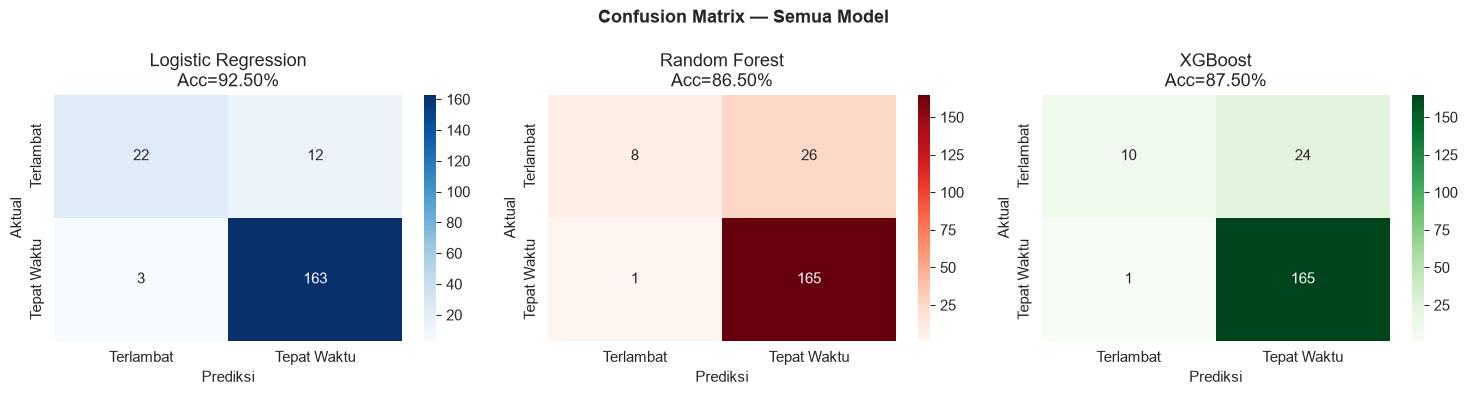

In [39]:
# ── Confusion Matrix ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix — Semua Model', fontsize=13, fontweight='bold')

for ax, (nama, model), color in zip(axes, best_models.items(), ['Blues','Reds','Greens']):
    yp = model.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['Terlambat','Tepat Waktu'],
                yticklabels=['Terlambat','Tepat Waktu'], ax=ax)
    acc = accuracy_score(y_test, yp)
    ax.set_title(f'{nama}\nAcc={acc:.2%}')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_all.png', dpi=150, bbox_inches='tight')
plt.show()


In [40]:
# ── Classification Report ────────────────────────────────────
best_model = best_models[best_name]
yp_best = best_model.predict(X_test)
print(f"CLASSIFICATION REPORT — {best_name}")
print("=" * 55)
print(classification_report(y_test, yp_best, target_names=['Terlambat','Tepat Waktu']))


CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

   Terlambat       0.88      0.65      0.75        34
 Tepat Waktu       0.93      0.98      0.96       166

    accuracy                           0.93       200
   macro avg       0.91      0.81      0.85       200
weighted avg       0.92      0.93      0.92       200



## 8. Learning Curve — Deteksi Overfitting

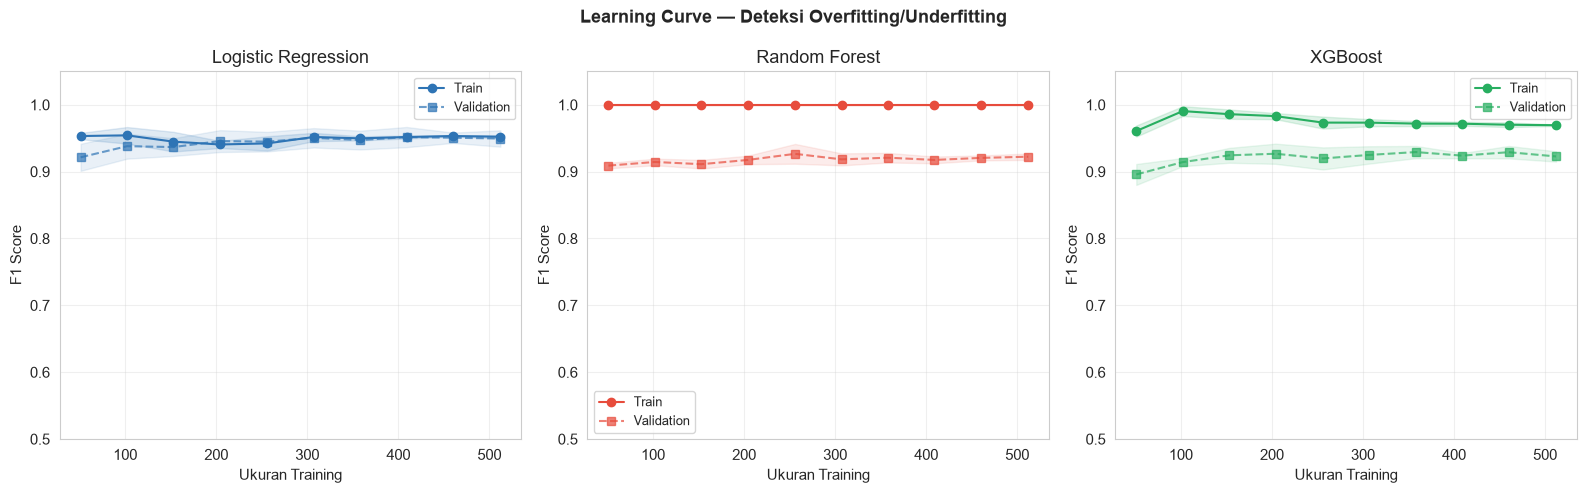

In [41]:
# ── Learning Curve ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Learning Curve — Deteksi Overfitting/Underfitting', fontsize=13, fontweight='bold')

for ax, (nama, model), color in zip(axes, best_models.items(), ['#2E74B5','#E74C3C','#27AE60']):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1,1.0,10), n_jobs=-1)
    
    tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
    vl_mean, vl_std = val_scores.mean(1), val_scores.std(1)
    
    ax.plot(train_sizes, tr_mean, 'o-', color=color, label='Train')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color=color)
    ax.plot(train_sizes, vl_mean, 's--', color=color, alpha=0.7, label='Validation')
    ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std, alpha=0.1, color=color)
    ax.set_title(nama); ax.set_xlabel('Ukuran Training'); ax.set_ylabel('F1 Score')
    ax.legend(fontsize=9); ax.set_ylim(0.5,1.05); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Interpretasi Model dengan SHAP

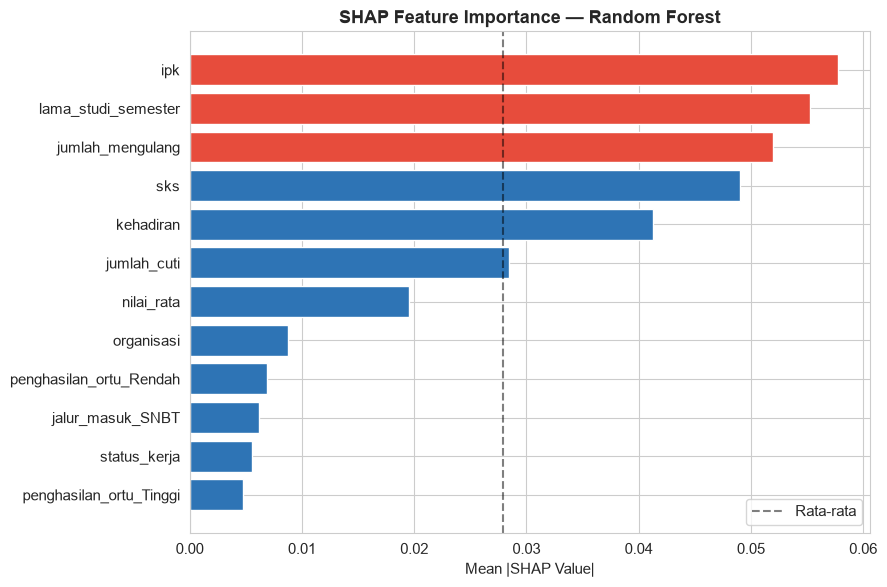


🔍 TOP 5 FITUR TERPENTING (SHAP):
   ipk                                 0.0577
   lama_studi_semester                 0.0552
   jumlah_mengulang                    0.0519
   sks                                 0.0491
   kehadiran                           0.0413


In [42]:
# ── SHAP Feature Importance ─────────────────────────────────
# Gunakan Random Forest untuk SHAP (TreeExplainer)
rf_model  = best_models['Random Forest']
prep      = rf_model.named_steps['prep']
rf        = rf_model.named_steps['model']
X_tr      = prep.transform(X_test)
ohe_cols  = prep.named_transformers_['cat'].get_feature_names_out(CAT)
all_cols  = NUM + list(ohe_cols)
X_proc    = pd.DataFrame(X_tr, columns=all_cols)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_proc)
sv = np.array(shap_values[1]) if isinstance(shap_values, list) else shap_values

# Feature Importance Plot
mean_shap = np.abs(sv).mean(axis=0)
if mean_shap.ndim > 1:
    mean_shap = mean_shap[:, 1] if mean_shap.shape[1] == 2 else mean_shap.ravel()

fi_df = pd.DataFrame({'Fitur':all_cols, 'SHAP':mean_shap}).sort_values('SHAP', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9,6))
colors = ['#E74C3C' if v >= fi_df['SHAP'].quantile(0.75) else '#2E74B5' for v in fi_df['SHAP']]
ax.barh(fi_df['Fitur'], fi_df['SHAP'], color=colors, edgecolor='white')
ax.axvline(fi_df['SHAP'].mean(), color='black', ls='--', alpha=0.5, label='Rata-rata')
ax.set_title('SHAP Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|'); ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 TOP 5 FITUR TERPENTING (SHAP):")
for _, row in fi_df.sort_values('SHAP',ascending=False).head(5).iterrows():
    print(f"   {row['Fitur']:<35} {row['SHAP']:.4f}")


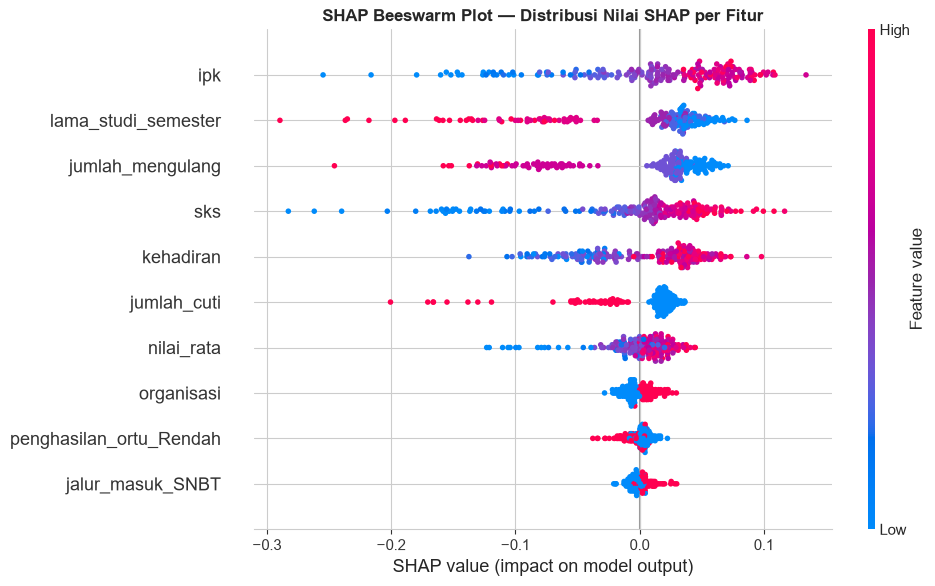

✅ SHAP Beeswarm plot: merah=nilai tinggi, biru=nilai rendah
   Posisi kanan = mendorong prediksi 'Tepat Waktu'


In [43]:
# ── SHAP Beeswarm Plot ──────────────────────────────────────
# Pastikan array sv diratakan menjadi 2D jika membawa dimensi kelas biner
sv_2d = sv[:, :, 1] if sv.ndim == 3 else sv

# Gunakan sv_2d untuk mencari indeks dan memotong data
top_idx  = np.argsort(np.abs(sv_2d).mean(axis=0))[-10:]
sv_top   = sv_2d[:, top_idx]
X_top    = X_proc.iloc[:, top_idx]
cols_top = [all_cols[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(sv_top, X_top, feature_names=cols_top, show=False, plot_size=None)
plt.title('SHAP Beeswarm Plot — Distribusi Nilai SHAP per Fitur', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SHAP Beeswarm plot: merah=nilai tinggi, biru=nilai rendah")
print("   Posisi kanan = mendorong prediksi 'Tepat Waktu'")

## 10. Simpan Model Terbaik

In [44]:
# ── Simpan Model ────────────────────────────────────────────
os.makedirs('../models', exist_ok=True)

best_model_obj = best_models[best_name]
joblib.dump(best_model_obj, '../models/best_model.pkl')
joblib.dump(best_models['Logistic Regression'], '../models/logistic_regression.pkl')
joblib.dump(best_models['XGBoost'], '../models/xgboost_model.pkl')
joblib.dump({'num':NUM,'cat':CAT}, '../models/feature_info.pkl')

X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)
X_train.to_csv('../data/processed/X_train.csv', index=False)

print("✅ SEMUA FILE TERSIMPAN:")
print(f"   models/best_model.pkl          → {best_name}")
print("   models/logistic_regression.pkl")
print("   models/xgboost_model.pkl")
print("   models/feature_info.pkl")
print("   data/processed/X_test.csv")
print("   data/processed/y_test.csv")
print("\n🎉 Pipeline ML selesai! Siap untuk deployment Streamlit.")


✅ SEMUA FILE TERSIMPAN:
   models/best_model.pkl          → Logistic Regression
   models/logistic_regression.pkl
   models/xgboost_model.pkl
   models/feature_info.pkl
   data/processed/X_test.csv
   data/processed/y_test.csv

🎉 Pipeline ML selesai! Siap untuk deployment Streamlit.
